МЕТОД К-БЛИЖАЙШИХ СОСЕДЕЙ(KMEANS)

KMeans оптимизирует конкретную цель (минимизирует сумму квадратов расстояний до центроидов). Поэтому результат зависит от масштаба признаков, начальной инициализации и формы кластеров (алгоритм “любит” примерно сферические кластеры).

Импорты

In [104]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import (
    KMeans, DBSCAN, 
    AgglomerativeClustering)
from sklearn.datasets import (
    make_blobs, load_iris,
    make_circles, make_moons,
    load_digits, load_wine)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    davies_bouldin_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score)

try:
    from scipy.cluster.hierarchy import dendrogram, linkage
except Exception as e:
    dendrogram = None
    linkage = None
    print("⚠️ SciPy не импортировался. Для дендрограммы установите scipy: pip install scipy")
    print("Причина:", repr(e))

rng=42
np.random.seed(rng)

Вспомогательные функции
plot_2d_points(...) — scatter + центры;
evaluate_k_range(...) — считает inertia_ и silhouette для диапазона K;
plot_k_metrics(...) — рисует графики метрик.

In [2]:
def plot_2d_points(X, labels=None, centers=None, title=None):
    # Рисует 2D-точки.
    # - X: массив формы (n_samples, 2)
    # - labels: метки кластеров (если есть)
    # - centers: центры кластеров (если есть)
    if X.shape[1] != 2:
        raise ValueError("plot_2d_points ожидает X с двумя признаками (n_samples, 2).")

    plt.figure(figsize=(7, 5))
    if labels is None:
        plt.scatter(X[:, 0], X[:, 1], s=25)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=labels, s=25)

    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=220, edgecolor="k")

    if title:
        plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.25)
    plt.show()

def evaluate_k_range(X, k_values, scale=False, random_state=42):
    # Для заданных K считает:
    # - inertia_ (ниже лучше)
    # - silhouette_score (выше лучше; определён для K>=2)
    #
    # Возвращает словарь с массивами метрик.
    X_work = X
    if scale:
        scaler = StandardScaler()
        X_work = scaler.fit_transform(X_work)

    inertias = []
    silhouettes = []

    for k in k_values:
        model = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        labels = model.fit_predict(X_work)

        inertias.append(model.inertia_)
        # silhouette определён только если кластеров >= 2 и есть хотя бы 2 разных кластера
        if k >= 2 and len(np.unique(labels)) > 1:
            silhouettes.append(silhouette_score(X_work, labels))
        else:
            silhouettes.append(np.nan)

    return {
        "k": np.array(list(k_values), dtype=int),
        "inertia": np.array(inertias, dtype=float),
        "silhouette": np.array(silhouettes, dtype=float),
        "scaled": bool(scale),
    }

def plot_k_metrics(metrics, title_suffix=""):
    k = metrics["k"]
    inertia = metrics["inertia"]
    sil = metrics["silhouette"]

    plt.figure(figsize=(7, 4))
    plt.plot(k, inertia, marker="o")
    plt.title(f"Inertia vs K{title_suffix}")
    plt.xlabel("K")
    plt.ylabel("inertia_ (ниже лучше)")
    plt.grid(True, alpha=0.25)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(k, sil, marker="o")
    plt.title(f"Silhouette vs K{title_suffix}")
    plt.xlabel("K")
    plt.ylabel("silhouette (выше лучше)")
    plt.grid(True, alpha=0.25)
    plt.show()

Создание датасетов

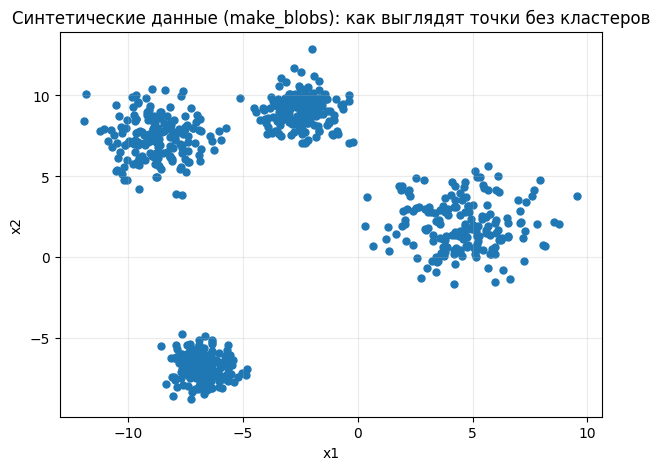

In [ ]:


X, y_true = make_blobs(
    n_samples=700,
    centers=4,
    cluster_std=[1.0, 1.6, 0.8, 1.2],
    random_state=rng
)

plot_2d_points(X, title="Синтетические данные (make_blobs): как выглядят точки без кластеров")

Обучение "в лоб"

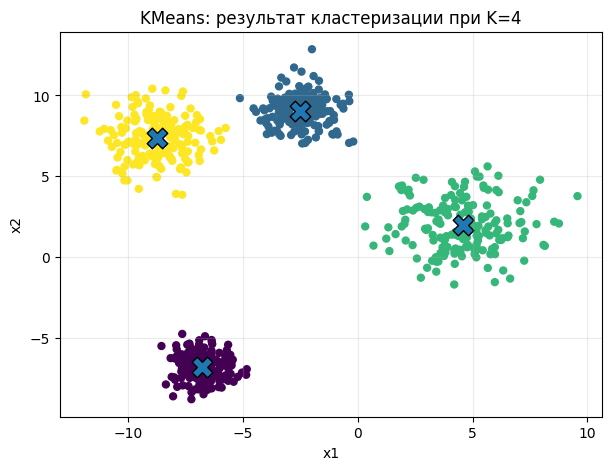

inertia_ = 1969.13
Число найденных кластеров = 4


In [4]:
k = 4
model = KMeans(n_clusters=k, n_init=10, random_state=rng)
labels = model.fit_predict(X)

plot_2d_points(
    X, labels=labels, centers=model.cluster_centers_,
    title=f"KMeans: результат кластеризации при K={k}"
)

print("inertia_ =", round(model.inertia_, 2))
print("Число найденных кластеров =", len(np.unique(labels)))

Масштабирование признаков

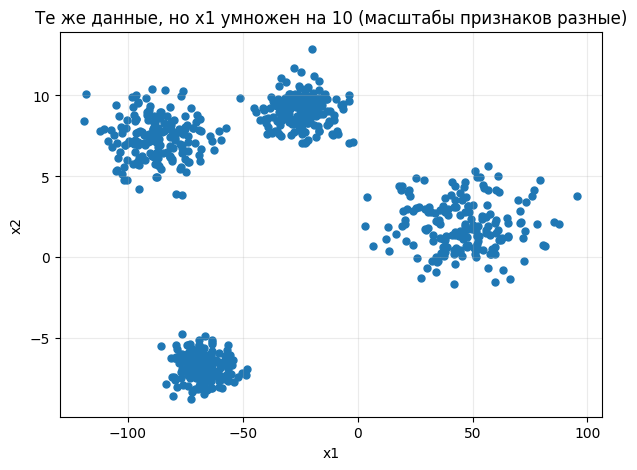

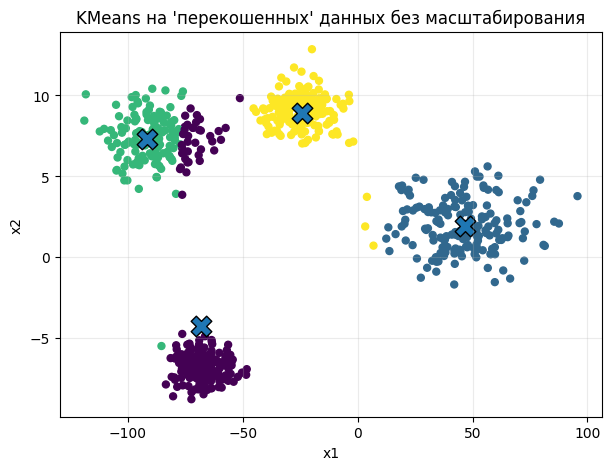

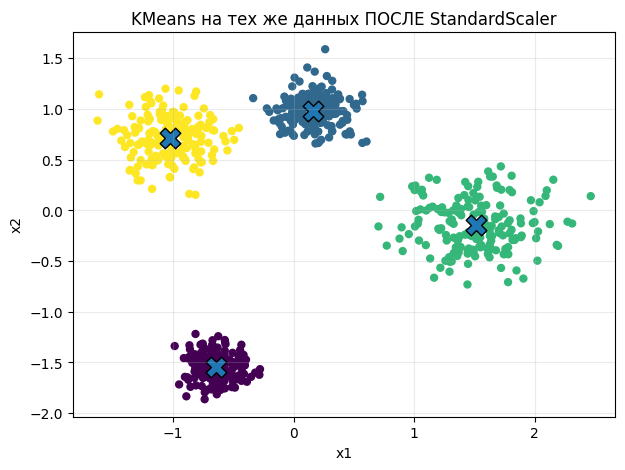

In [5]:
X_skew = X.copy()
X_skew[:, 0] *= 10  # искусственно увеличим масштаб первого признака

plot_2d_points(X_skew, title="Те же данные, но x1 умножен на 10 (масштабы признаков разные)")

model_bad = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_bad = model_bad.fit_predict(X_skew)

plot_2d_points(
    X_skew, labels=labels_bad, centers=model_bad.cluster_centers_,
    title="KMeans на 'перекошенных' данных без масштабирования"
)

# Теперь исправим ситуацию StandardScaler'ом
scaler = StandardScaler()
X_skew_scaled = scaler.fit_transform(X_skew)

model_good = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_good = model_good.fit_predict(X_skew_scaled)

plot_2d_points(
    X_skew_scaled, labels=labels_good, centers=model_good.cluster_centers_,
    title="KMeans на тех же данных ПОСЛЕ StandardScaler"
)

Для KMeans почти всегда нужно использовать StandardScaler

Параметр n_init говорит, сколько раз запускать алгоритм с разными инициализациями и выбирать лучший по inertia_.

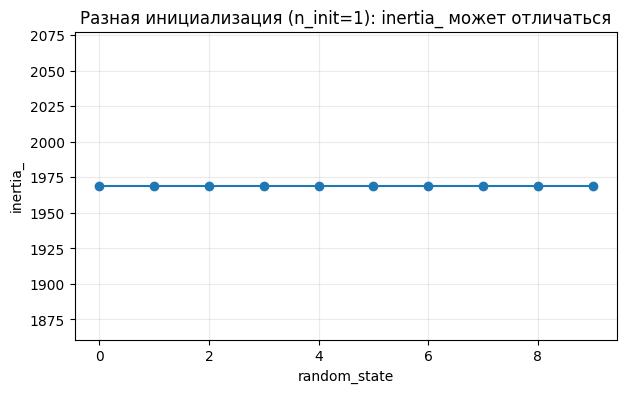

min inertia: 1969.13
max inertia: 1969.13


In [6]:
inertias = []
states = list(range(10))

for rs in states:
    m = KMeans(n_clusters=4, n_init=1, random_state=rs)
    m.fit(X)
    inertias.append(m.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(states, inertias, marker="o")
plt.title("Разная инициализация (n_init=1): inertia_ может отличаться")
plt.xlabel("random_state")
plt.ylabel("inertia_")
plt.grid(True, alpha=0.25)
plt.show()

print("min inertia:", round(float(np.min(inertias)), 2))
print("max inertia:", round(float(np.max(inertias)), 2))

Сравнение при n_init=1 и n_init=10

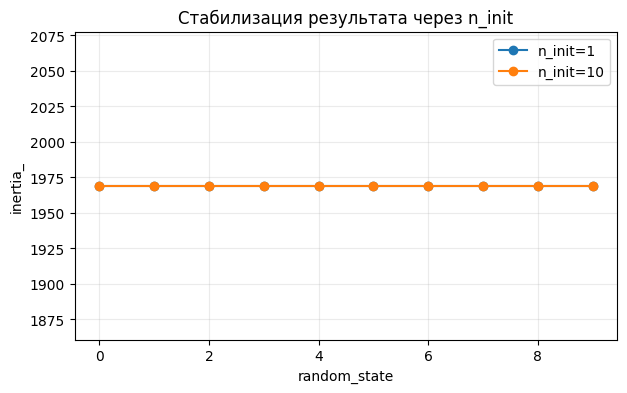

In [7]:
# Сравним разброс inertia_ при n_init=1 и n_init=10
inertias_1 = []
inertias_10 = []

for rs in states:
    m1 = KMeans(n_clusters=4, n_init=1, random_state=rs)
    m1.fit(X)
    inertias_1.append(m1.inertia_)

    m10 = KMeans(n_clusters=4, n_init=10, random_state=rs)
    m10.fit(X)
    inertias_10.append(m10.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(states, inertias_1, marker="o", label="n_init=1")
plt.plot(states, inertias_10, marker="o", label="n_init=10")
plt.title("Стабилизация результата через n_init")
plt.xlabel("random_state")
plt.ylabel("inertia_")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

Elbow method (локоть) по inertia_

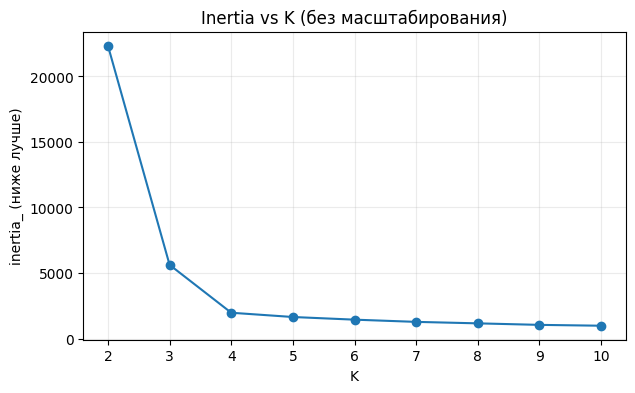

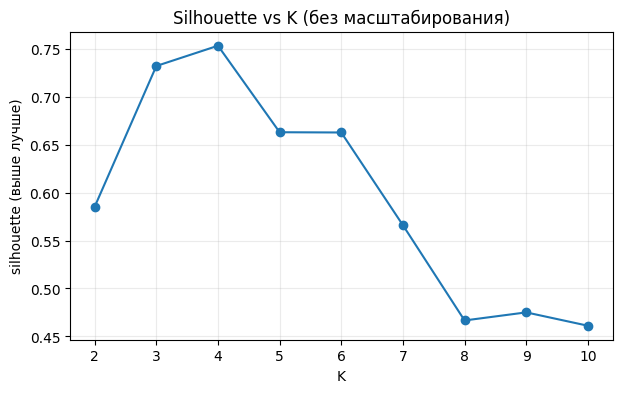

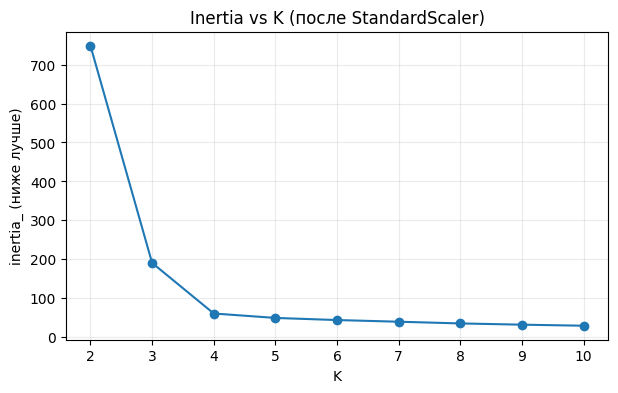

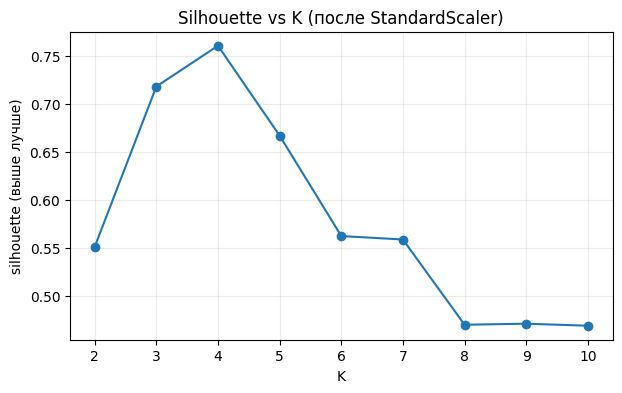

In [8]:
k_values = range(2,11)

mertics_raw = evaluate_k_range(X, k_values, scale=False, random_state=rng)
plot_k_metrics(mertics_raw, title_suffix=" (без масштабирования)")

metrics_scaled = evaluate_k_range(X, k_values, scale=True, random_state=rng)
plot_k_metrics(metrics_scaled, title_suffix=" (после StandardScaler)")


Silhouette score (силуэт)

Точка должна быть
близко к точкам своего кластера,
и далеко от ближайшего “чужого” кластера.

Эксперимент на реальном датасете (Iris)

Нужно отмасштабировать признаки

In [9]:
iris = load_iris()
X_iris = iris.data

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

k = 3
model_iris = KMeans(n_clusters=k, n_init=20, random_state=rng)
labels_iris = model_iris.fit_predict(X_iris_scaled)

print("Iris: inertia_ =", round(model_iris.inertia_, 3))
print("Iris: silhouette =", round(silhouette_score(X_iris_scaled, labels_iris), 3))
print("Размеры кластеров:", np.bincount(labels_iris))


Iris: inertia_ = 139.82
Iris: silhouette = 0.46
Размеры кластеров: [53 50 47]


Итоги
KMeans – простой и быстрый базовый алгоритм кластеризации, но он чувствителен к масштабам признаков и предполагает “примерно сферические” кластеры.
Перед KMeans почти всегда стоит попробовать StandardScaler.
Для выбора K полезны:
elbow по inertia_;
silhouette score;
и здравый смысл: интерпретируемость и устойчивость результата.

DBSCAN

умеет находить кластеры произвольной формы;
умеет помечать точки как шум (-1), вместо того чтобы “кластеризовать всё любой ценой”;
не требует заранее задавать число кластеров K.

Вспомогательные функции

In [10]:
def plot_points(X, title="", ax=None):
    """Базовый scatter для 2D-точек."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[:, 0], X[:, 1], s=20)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.25)
    return ax

def plot_dbscan(X, labels, title="", ax=None):
    """Визуализация результата DBSCAN: кластеры + шум."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    labels = np.asarray(labels)
    unique = sorted(set(labels))

    for lab in unique:
        mask = labels == lab
        if lab == -1:
            ax.scatter(X[mask, 0], X[mask, 1], s=20, marker="x", label="noise (-1)")
        else:
            ax.scatter(X[mask, 0], X[mask, 1], s=20, label=f"cluster {lab}")

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    return ax

def summarize_labels(labels):
    """Короткая статистика по разметке: число кластеров, доля шума."""
    labels = np.asarray(labels)
    n_noise = np.sum(labels == -1)
    n_points = len(labels)
    clusters = sorted([c for c in set(labels) if c != -1])
    return {
        "n_points": n_points,
        "n_clusters": len(clusters),
        "n_noise": int(n_noise),
        "noise_share": float(n_noise / n_points)
    }

def safe_internal_metrics(X, labels):
    """Внутренние метрики для кластеров.

    Важно:
    - silhouette корректно считать, когда есть >=2 кластера.
    - шум (-1) лучше исключать из расчёта, иначе метрика становится трудно интерпретируемой.
    """
    labels = np.asarray(labels)
    mask = labels != -1
    X2 = X[mask]
    y2 = labels[mask]

    result = {}

    # если осталось меньше 2 кластеров – метрики бессмысленны
    if len(set(y2)) < 2:
        result["silhouette"] = None
        result["calinski_harabasz"] = None
        result["davies_bouldin"] = None
        return result

    result["silhouette"] = float(silhouette_score(X2, y2))
    result["calinski_harabasz"] = float(calinski_harabasz_score(X2, y2))
    result["davies_bouldin"] = float(davies_bouldin_score(X2, y2))
    return result

DBSCAN строит кластеры через понятие плотности:

eps – радиус окрестности точки;
min_samples – сколько точек нужно иметь в eps-окрестности, чтобы точка считалась ядром (core).
Типы точек:

core: внутри eps есть хотя бы min_samples точек;
border: сама не core, но попадает в окрестность какого-то core;
noise: не core и не border (обозначается меткой -1).
Кластеры – это связные компоненты из core-точек (плюс их border-точки).

make_moons

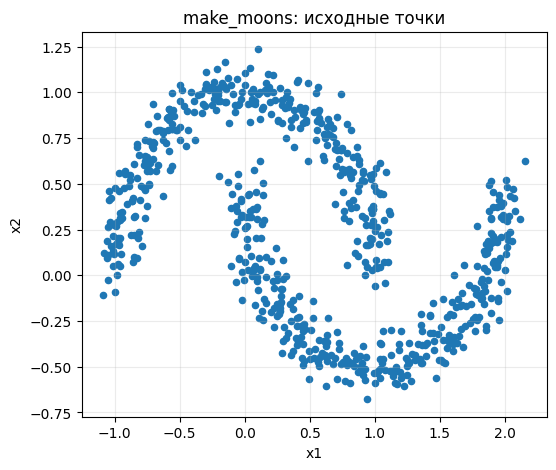

In [17]:
X_moons, _ = make_moons(n_samples=700, noise=0.08, random_state=rng)

plot_points(X_moons, title="make_moons: исходные точки")
plt.show()

Базовый запуск

In [18]:
db = DBSCAN(eps=0.20, min_samples=5)
labels = db.fit_predict(X_moons)

stats = summarize_labels(labels)
mertics = safe_internal_metrics(X_moons, labels)

stats, mertics


({'n_points': 700, 'n_clusters': 2, 'n_noise': 0, 'noise_share': 0.0},
 {'silhouette': 0.32592319594863595,
  'calinski_harabasz': 448.9312325523609,
  'davies_bouldin': 1.170641753559647})

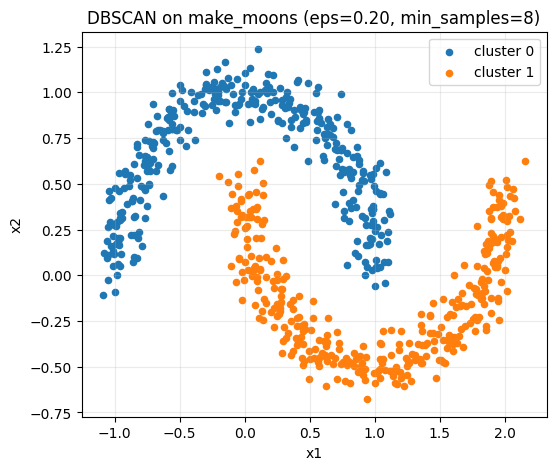

In [19]:
plot_dbscan(X_moons, labels, title="DBSCAN on make_moons (eps=0.20, min_samples=8)")
plt.show()

Если eps слишком маленький → почти всё станет noise.
Если eps слишком большой → кластеры сольются в один большой.
min_samples регулирует «строгость» плотности: больше min_samples → больше шума, меньше ложных кластеров.

Масштабирование

DBSCAN основан на расстояниях.
Если один признак измеряется в «крупных» единицах, а другой – в «мелких», то расстояние будет доминировать одним измерением.

Сравнение с и без StandardScaler

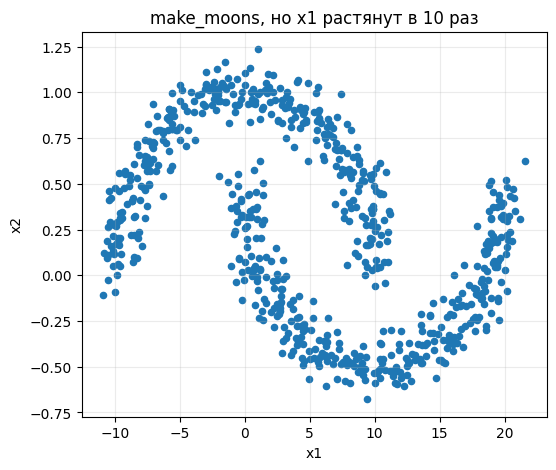

In [20]:
X_scaled_axis = X_moons.copy()
X_scaled_axis[:, 0] *= 10.0

fig, ax = plt.subplots(figsize=(6,5))
plot_points(X_scaled_axis, title="make_moons, но x1 растянут в 10 раз", ax=ax)
plt.show()


DBSCAN на плохом масштабе

In [21]:
db_bad = DBSCAN(eps=0.20, min_samples=8)
labels_bed = db_bad.fit_predict(X_scaled_axis)

summarize_labels(labels_bad), safe_internal_metrics(X_scaled_axis, labels_bad)

({'n_points': 700, 'n_clusters': 4, 'n_noise': 0, 'noise_share': 0.0},
 {'silhouette': -0.04876020271171612,
  'calinski_harabasz': 0.8157112493212071,
  'davies_bouldin': 122.95225512303347})

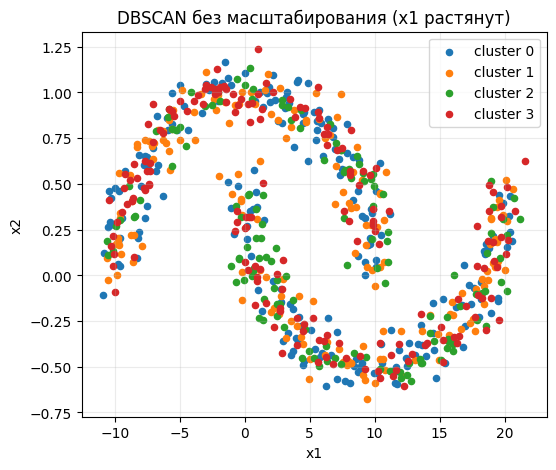

In [22]:
plot_dbscan(X_scaled_axis, labels_bad, title="DBSCAN без масштабирования (x1 растянут)")
plt.show()

Добавление масштабирования

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scaled_axis)

db_good = DBSCAN(eps=0.20, min_samples=8)
labels_good = db_good.fit_predict(X_scaled)

summarize_labels(labels_good), safe_internal_metrics(X_scaled, labels_good)

({'n_points': 700,
  'n_clusters': 2,
  'n_noise': 9,
  'noise_share': 0.012857142857142857},
 {'silhouette': 0.3890148604750729,
  'calinski_harabasz': 607.4638950659967,
  'davies_bouldin': 1.0135732731593547})

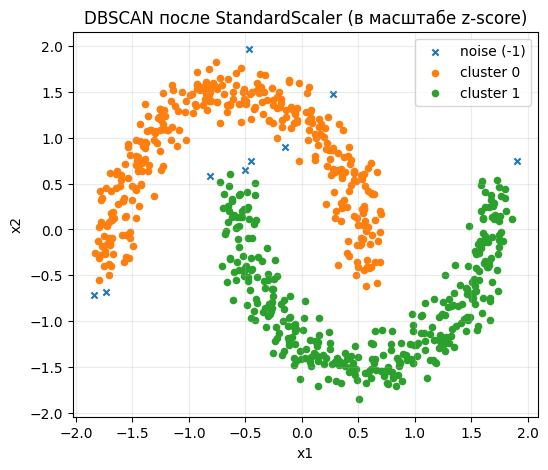

In [25]:
plot_dbscan(X_scaled, labels_good, title="DBSCAN после StandardScaler (в масштабе z-score)")
plt.show()

Когда используеться DBSCAN или любой другой метод на расстоянии, масштабирование - часть решения

k-distance plot для подбора eps

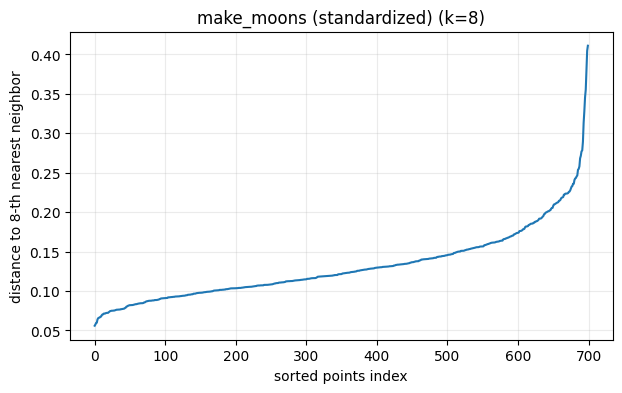

In [27]:
def k_distance_plot(X, k=8, title="k-distance plot"):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)  # distances shape: (n_samples, k)

    kth = np.sort(distances[:, -1])  # расстояние до k-го соседа
    plt.figure(figsize=(7, 4))
    plt.plot(kth)
    plt.title(f"{title} (k={k})")
    plt.xlabel("sorted points index")
    plt.ylabel(f"distance to {k}-th nearest neighbor")
    plt.grid(True, alpha=0.25)
    plt.show()

    return kth

X_moons_std = StandardScaler().fit_transform(X_moons)
kth = k_distance_plot(X_moons_std, k=8, title="make_moons (standardized)")

Подбор eps

In [41]:
eps = 0.23
min_samples = 8

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_moons_std)

summarize_labels(labels), safe_internal_metrics(X_moons_std, labels)

({'n_points': 700,
  'n_clusters': 2,
  'n_noise': 3,
  'noise_share': 0.004285714285714286},
 {'silhouette': 0.38504593636974643,
  'calinski_harabasz': 601.0201883613522,
  'davies_bouldin': 1.02288784814566})

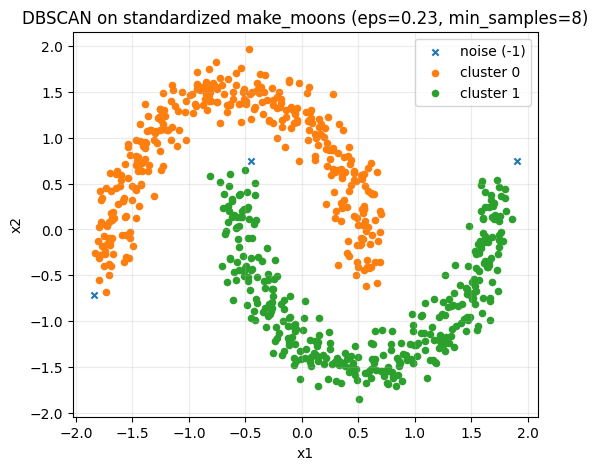

In [42]:
plot_dbscan(X_moons_std, labels, title=f"DBSCAN on standardized make_moons (eps={eps}, min_samples={min_samples})")
plt.show()

Обзор чувствительности параметров

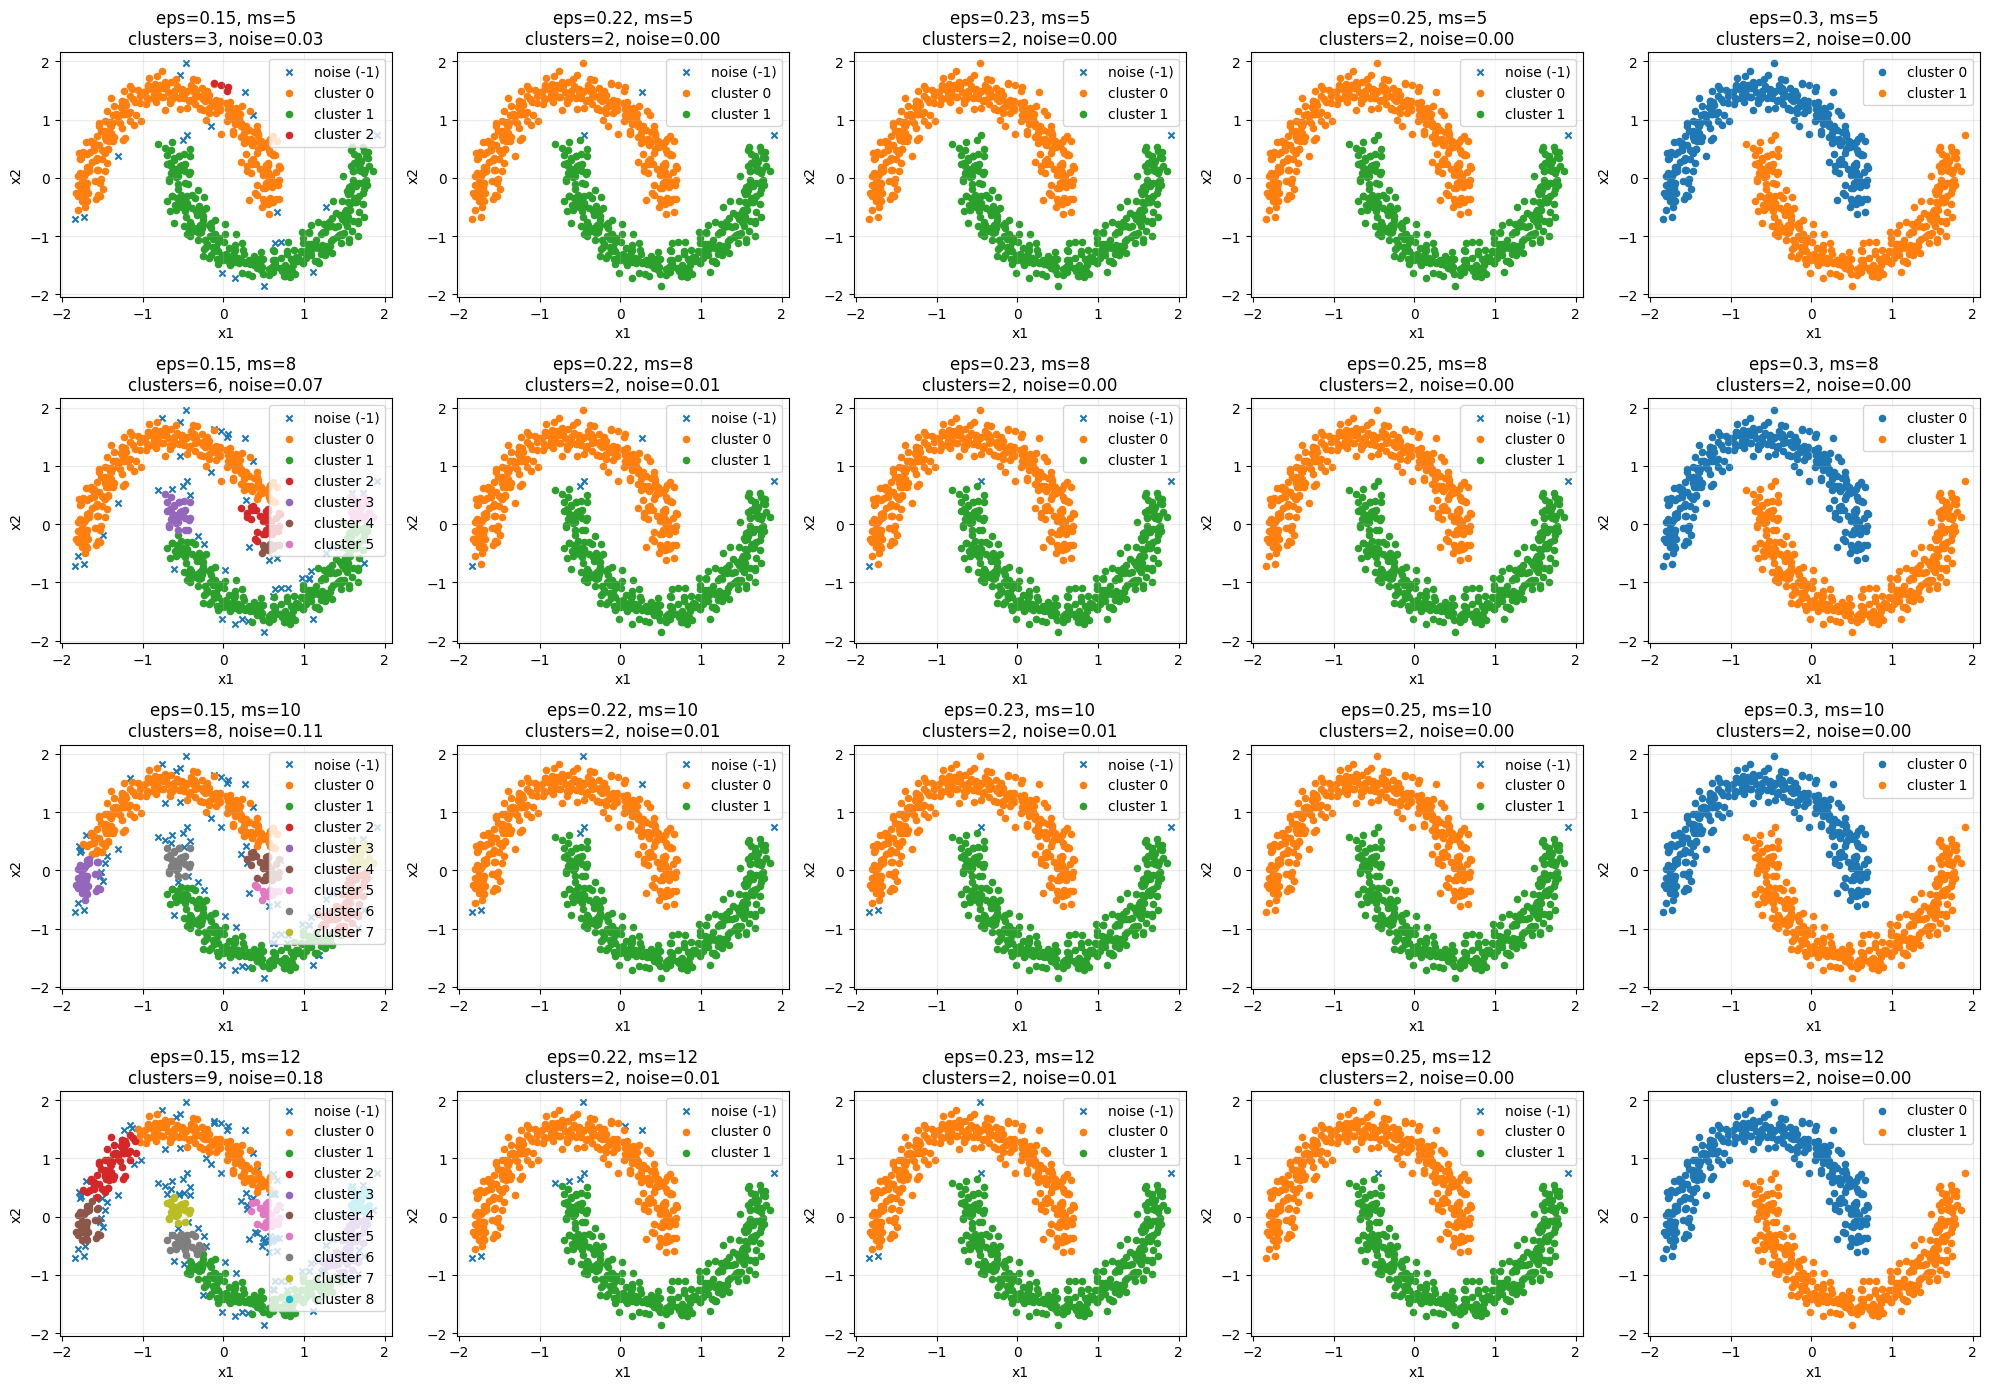

In [44]:
eps_list = [0.15, 0.22, 0.23, 0.25, 0.30]
min_samples_list = [5, 8, 10, 12]

X = X_moons_std

fig, axes = plt.subplots(len(min_samples_list), len(eps_list), figsize=(4*len(eps_list), 3.5*len(min_samples_list)))
for i, ms in enumerate(min_samples_list):
    for j, eps in enumerate(eps_list):
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        stats = summarize_labels(labels)
        ax = axes[i, j]
        plot_dbscan(X, labels, title=f"eps={eps}, ms={ms}\nclusters={stats['n_clusters']}, noise={stats['noise_share']:.2f}", ax=ax)

plt.tight_layout()
plt.show()

make_circles (вложенные окружности)

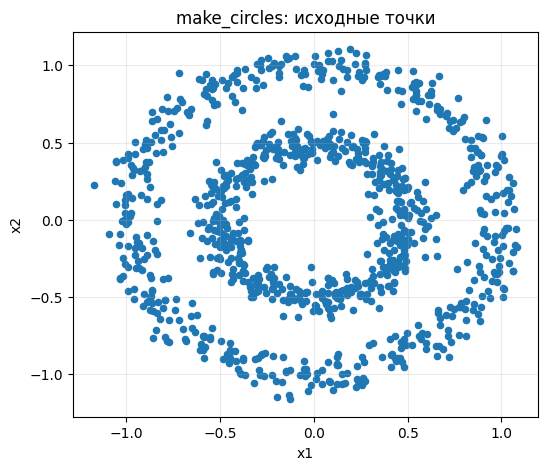

In [49]:
X_circles, _ = make_circles(n_samples=1000, noise=0.07, factor=0.5, random_state=42)
X_circles_std = StandardScaler().fit_transform(X_circles)

plot_points(X_circles, title="make_circles: исходные точки")
plt.show()

In [50]:
eps = 0.25
min_samples = 10

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_circles_std)

summarize_labels(labels), safe_internal_metrics(X_circles_std, labels)

({'n_points': 1000, 'n_clusters': 2, 'n_noise': 0, 'noise_share': 0.0},
 {'silhouette': 0.10930938479172181,
  'calinski_harabasz': 0.0022005424332204072,
  'davies_bouldin': 637.7064360193173})

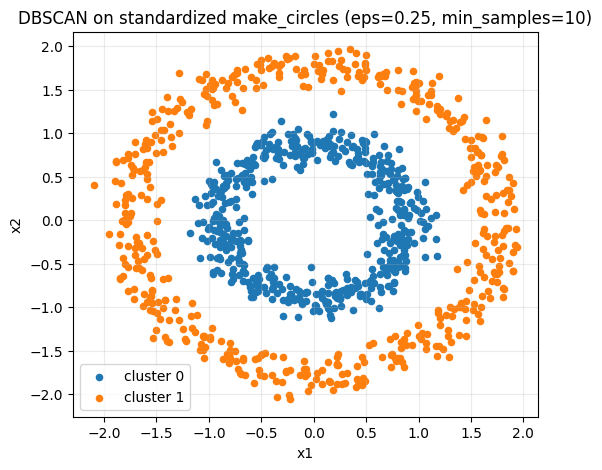

In [51]:
plot_dbscan(X_circles_std, labels, title=f"DBSCAN on standardized make_circles (eps={eps}, min_samples={min_samples})")
plt.show()

Разная плотность кластеров

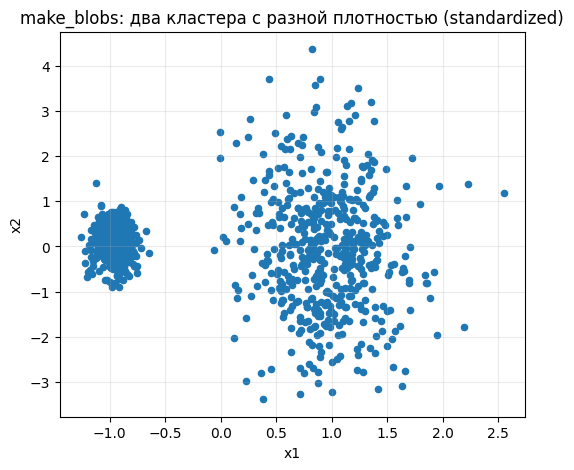

In [52]:
X1, _ = make_blobs(n_samples=500, centers=[(-2, 0)], cluster_std=0.20, random_state=1)
X2, _ = make_blobs(n_samples=500, centers=[(2, 0)], cluster_std=0.80, random_state=2)
X_var = np.vstack([X1, X2])

X_var_std = StandardScaler().fit_transform(X_var)
plot_points(X_var_std, title="make_blobs: два кластера с разной плотностью (standardized)")
plt.show()

In [78]:
eps = 0.55
min_samples = 2

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_var_std)

summarize_labels(labels), safe_internal_metrics(X_var_std, labels)

({'n_points': 1000, 'n_clusters': 2, 'n_noise': 1, 'noise_share': 0.001},
 {'silhouette': 0.5529815226379666,
  'calinski_harabasz': 872.830448766993,
  'davies_bouldin': 0.7613002108326421})

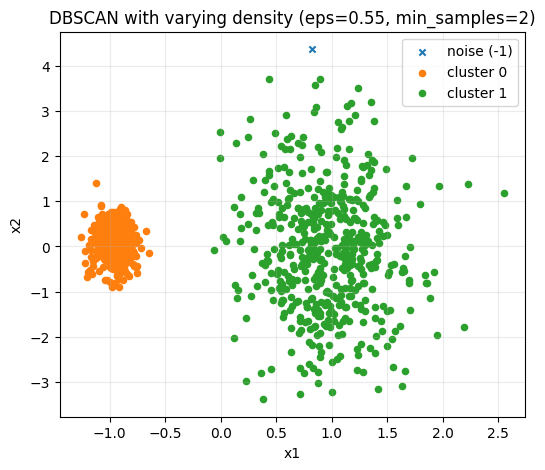

In [79]:
plot_dbscan(X_var_std, labels, title=f"DBSCAN with varying density (eps={eps}, min_samples={min_samples})")
plt.show()

Что из этого следует
DBSCAN – отличный базовый метод для:

кластеров произвольной формы,
задач с выбросами,
когда K неизвестно.
Но у него есть ограничения:

чувствительность к eps/min_samples,
сложности при разной плотности кластеров,
зависимость от метрики расстояния и масштабирования.

Иерархическая кластеризация и дендрограмма

Интуиция: что происходит в агломеративной кластеризации
Агломеративная кластеризация начинается с того, что каждая точка – это отдельный кластер. Дальше алгоритм многократно:

находит два ближайших кластера,
объединяет их,
пересчитывает расстояния до нового кластера,
пока не останется один большой кластер (или пока не достигнем нужного числа кластеров / порога расстояния).

Ключевой вопрос: как измерять расстояние между кластерами? Этим управляет linkage:

single: расстояние = минимальная дистанция между точками (часто даёт “цепочки”);
complete: расстояние = максимальная дистанция (стремится к компактности);
average: средняя дистанция;
ward: объединяем так, чтобы минимально увеличивалась внутрикластерная дисперсия (часто хорош для “шариков”).
Если признаки в разных шкалах, расстояния будут “перекошены”, поэтому обычно делаем StandardScaler.

In [95]:
def plot_pca_2d(X, labels, title):
    """Простая 2D-визуализация кластеров через PCA."""
    pca = PCA(n_components=2, random_state=rng)
    X2 = pca.fit_transform(X)

    plt.figure(figsize=(7, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=35)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.25)
    plt.show()

def cluster_sizes(labels):
    """Размеры кластеров (сколько точек в каждом)."""
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique.tolist(), counts.tolist()))


В датасете iris 3 вида ирисов, но мы делаем вид, что этих меток нет

In [83]:
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

print("X.shape:", X.shape)
print("Признаки:", feature_names)

X.shape: (150, 4)
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [84]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("После scaling: mean ~", X_scaled.mean(axis=0).round(3))
print("После scaling: std  ~", X_scaled.std(axis=0).round(3))

После scaling: mean ~ [-0. -0. -0. -0.]
После scaling: std  ~ [1. 1. 1. 1.]


Дендрограмма – “дерево” последовательных объединений кластеров.

по оси X: объекты (или группы объектов);
по оси Y: расстояние объединения (насколько “далеко” были объединяемые кластеры).
Чем выше происходит объединение, тем менее похожи были объединяемые кластеры. По дендрограмме часто выбирают число кластеров: “режем” дерево горизонтальной линией.

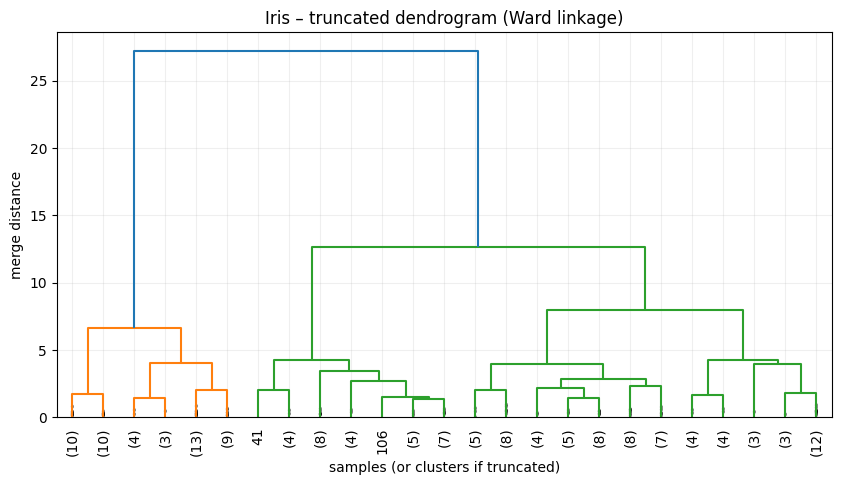

In [86]:
def plot_dendrogram(X_scaled, method="ward", truncate_mode=None, p=30, title=None):
    if linkage is None or dendrogram is None:
        print("SciPy недоступен – пропускаем дендрограмму.")
        return

    Z = linkage(X_scaled, method=method)
    plt.figure(figsize=(10, 5))
    dendrogram(
        Z,
        truncate_mode=truncate_mode,
        p=p,
        leaf_rotation=90,
        leaf_font_size=10,
        show_contracted=True
    )
    plt.title(title or f"Dendrogram (linkage='{method}')")
    plt.xlabel("samples (or clusters if truncated)")
    plt.ylabel("merge distance")
    plt.grid(True, alpha=0.2)
    plt.show()
    return Z

# Полная дендрограмма на 150 объектах будет слишком плотной,
# поэтому используем "truncated" вариант (показываем верхние уровни).
Z_ward = plot_dendrogram(
    X_scaled,
    method="ward",
    truncate_mode="lastp",
    p=25,
    title="Iris – truncated dendrogram (Ward linkage)"
)

Изменение дендрограммы от linkage

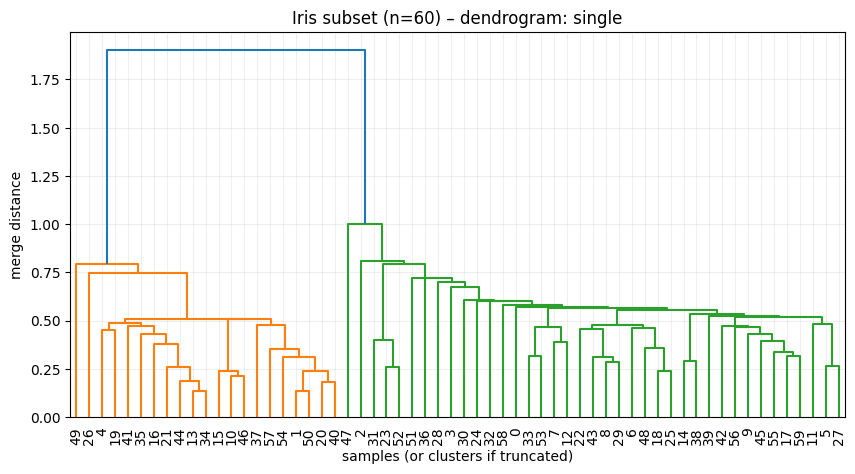

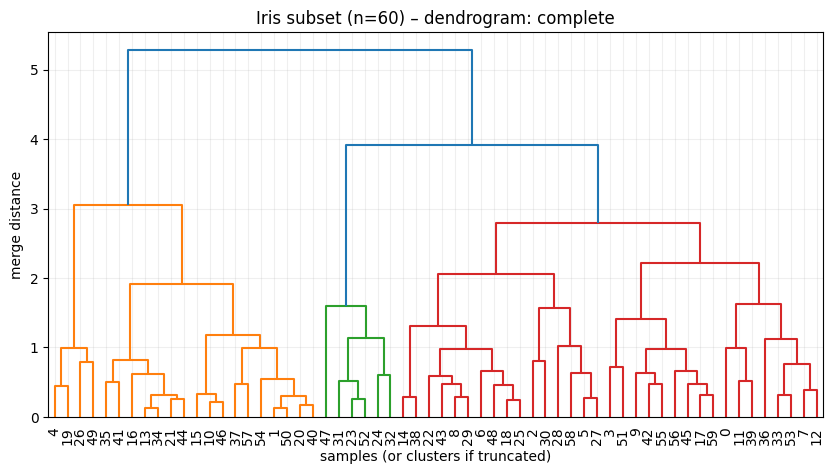

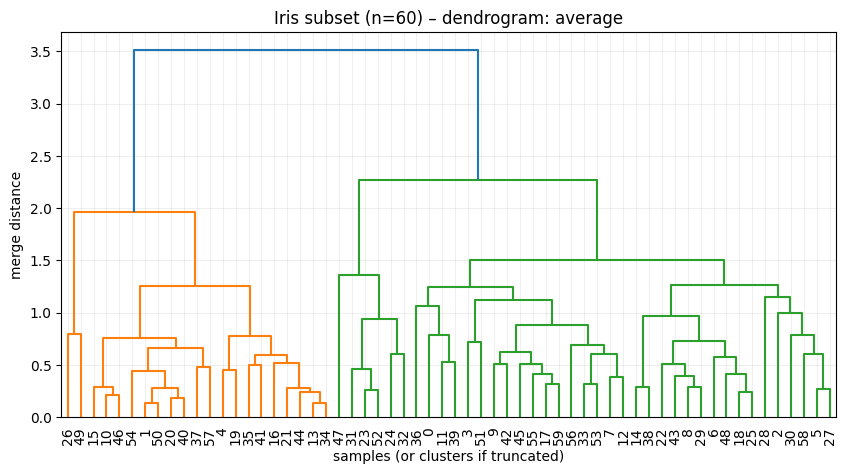

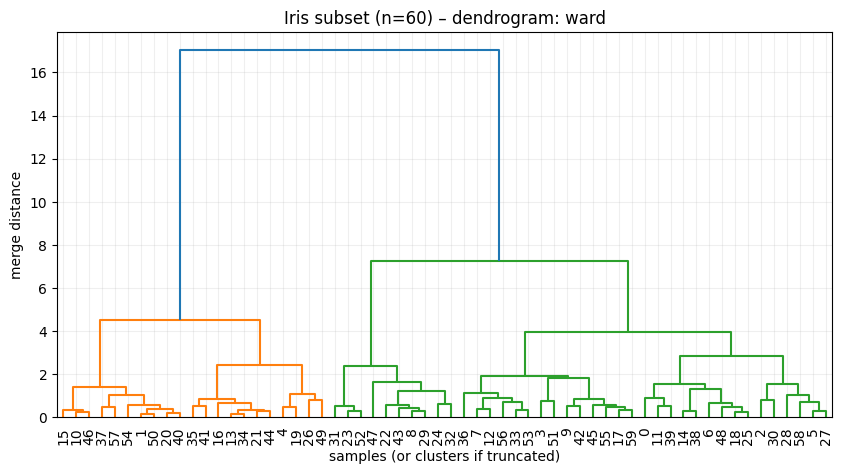

In [ ]:
subset_idx = np.random.choice(len(X_scaled), size=60, replace=False)
X_sub = X_scaled[subset_idx]

for method in ["single", "complete", "average", "ward"]:
    _ = plot_dendrogram(
        X_sub,
        method=method,
        truncate_mode=None,
        p=30,
        title=f"Iris subset (n=60) – dendrogram: {method}"
    )

Выбор числа класеров

Есть два типичных подхода:

по дендрограмме: ищем “большие скачки” по высоте (между объединениями) и режем там;
по внутренним метрикам: например, silhouette (чем выше – тем лучше, но это не абсолютная истина).

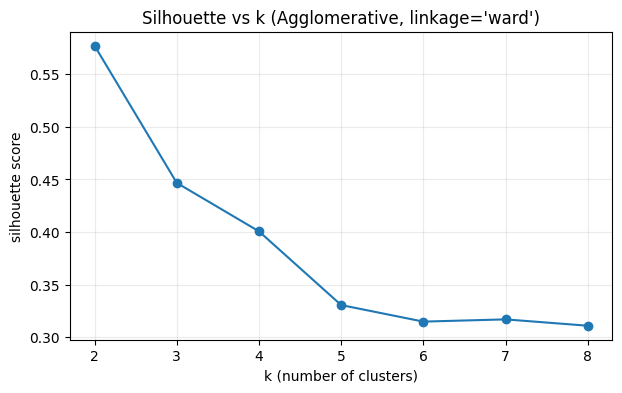

Best k by silhouette: 2 (score=0.577)


In [93]:
def silhouette_over_k(X_scaled, linkage_name="ward", k_min=2, k_max=10):
    ks = []
    scores = []

    for k in range(k_min, k_max + 1):
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
        labels = model.fit_predict(X_scaled)

        # silhouette требует минимум 2 кластера и чтобы не было "всё в один"
        score = silhouette_score(X_scaled, labels)
        ks.append(k)
        scores.append(score)

    plt.figure(figsize=(7, 4))
    plt.plot(ks, scores, marker="o")
    plt.title(f"Silhouette vs k (Agglomerative, linkage='{linkage_name}')")
    plt.xlabel("k (number of clusters)")
    plt.ylabel("silhouette score")
    plt.grid(True, alpha=0.25)
    plt.show()

    best_k = ks[int(np.argmax(scores))]
    best_score = float(np.max(scores))
    print(f"Best k by silhouette: {best_k} (score={best_score:.3f})")

silhouette_over_k(X_scaled, linkage_name="ward", k_min=2, k_max=8)

Обучение модели с выбранным k

Cluster sizes: {0: 71, 1: 49, 2: 30}


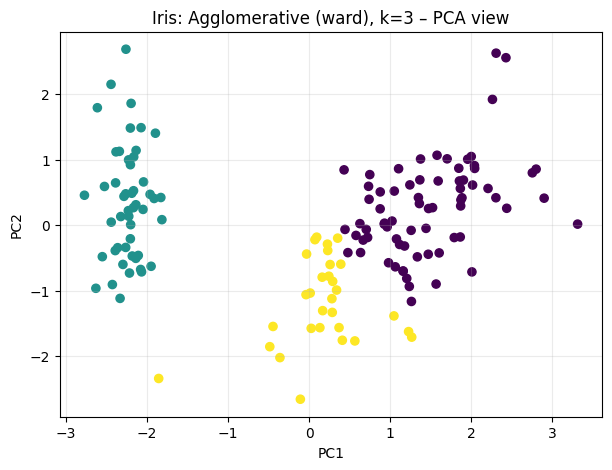

In [100]:
k = 3
model = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels = model.fit_predict(X_scaled)

print("Cluster sizes:", cluster_sizes(labels))
plot_pca_2d(X_scaled, labels, f"Iris: Agglomerative (ward), k={k} – PCA view")

Датасет make_blobes

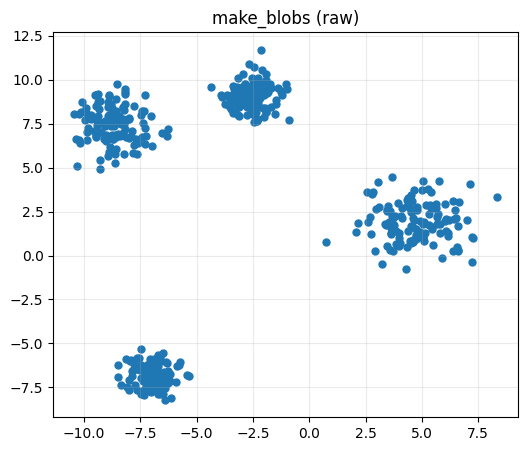

In [101]:
Xb, _ = make_blobs(
    n_samples=500,
    centers=4,
    n_features=2,
    cluster_std=[0.7, 1.2, 0.6, 1.0],
    random_state=rng
)

plt.figure(figsize=(6, 5))
plt.scatter(Xb[:, 0], Xb[:, 1], s=25)
plt.title("make_blobs (raw)")
plt.grid(True, alpha=0.25)
plt.show()

Xb_scaled = StandardScaler().fit_transform(Xb)


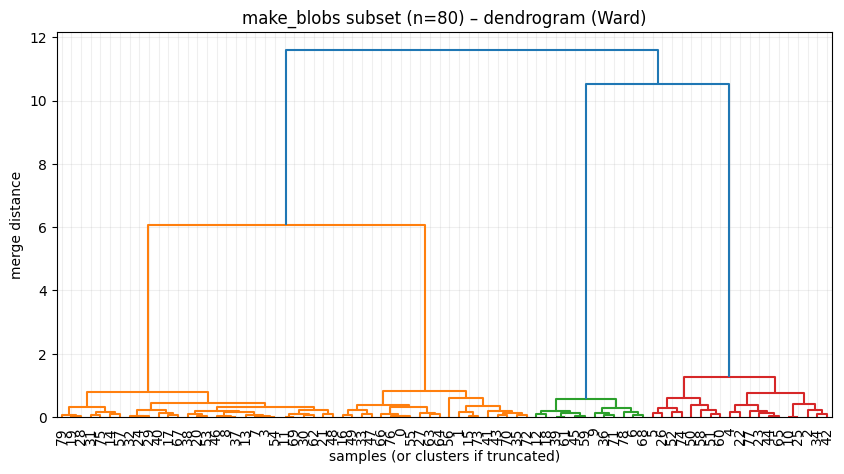

In [102]:
subset_idx = np.random.choice(len(Xb_scaled), size=80, replace=False)
_ = plot_dendrogram(
    Xb_scaled[subset_idx],
    method="ward",
    truncate_mode=None,
    p=30,
    title="make_blobs subset (n=80) – dendrogram (Ward)"
)

Подбор k по silhouette

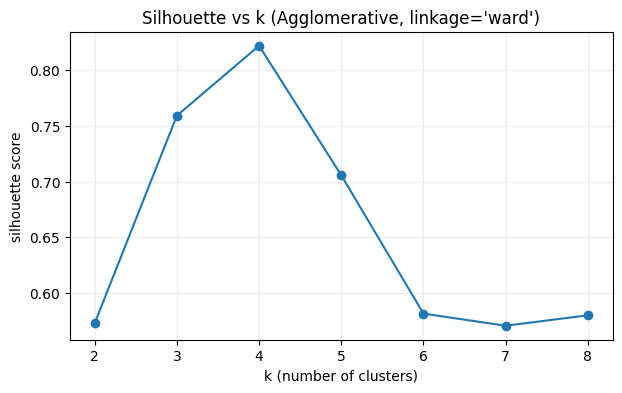

Best k by silhouette: 4 (score=0.822)
Cluster sizes: {0: 125, 1: 125, 2: 125, 3: 125}


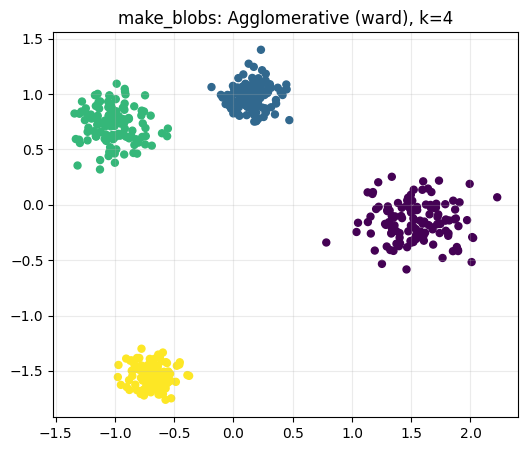

In [103]:
silhouette_over_k(Xb_scaled, linkage_name="ward", k_min=2, k_max=8)

k = 4
model_b = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_b = model_b.fit_predict(Xb_scaled)

print("Cluster sizes:", cluster_sizes(labels_b))
plt.figure(figsize=(6, 5))
plt.scatter(Xb_scaled[:, 0], Xb_scaled[:, 1], c=labels_b, s=25)
plt.title(f"make_blobs: Agglomerative (ward), k={k}")
plt.grid(True, alpha=0.25)
plt.show()

Выводы:

Иерархическая кластеризация “строит дерево” объединений; дендрограмма – визуализация этого дерева.
Linkage – ключевой выбор: он определяет, что значит “кластеры близки”.
Масштабирование признаков обычно критично.
Внутренние метрики (например, silhouette) помогают сравнивать варианты, но их важно интерпретировать вместе с визуализацией и здравым смыслом.

Метрики кластеризации + PCA + t-SNE

Данные Digits (64 признака)

load_digits() возвращает:

data: матрицу признаков (n_samples × 64),
images: сами картинки 8×8,
target: истинные цифры 0..9 (в этом демо используем только как учебный контроль).

In [105]:
digits = load_digits()
X = digits.data
y_true = digits.target

print("X.shape:", X.shape)
print("y_true classes:", np.unique(y_true))

X.shape: (1797, 64)
y_true classes: [0 1 2 3 4 5 6 7 8 9]


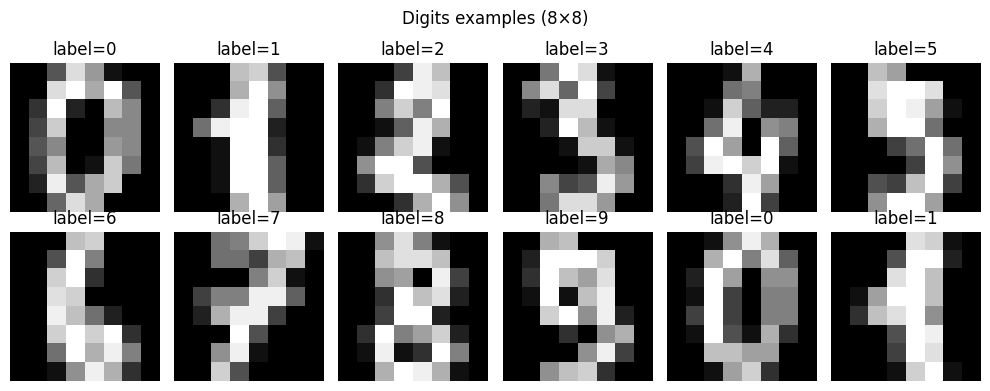

In [106]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(12)):
    ax.imshow(digits.images[idx], cmap="gray")
    ax.set_title(f"label={y_true[idx]}")
    ax.axis("off")
plt.suptitle("Digits examples (8×8)")
plt.tight_layout()
plt.show()

In [107]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled: mean ~", X_scaled.mean(axis=0).round(3)[:5], "...")
print("Scaled: std  ~", X_scaled.std(axis=0).round(3)[:5], "...")


Scaled: mean ~ [ 0. -0. -0. -0.  0.] ...
Scaled: std  ~ [0. 1. 1. 1. 1.] ...


Внутренние метрики качества

Три базовые внутренние метрики:

Silhouette (выше – лучше): насколько точки ближе к своему кластеру, чем к соседнему.
Davies-Bouldin (ниже – лучше): баланс компактности кластеров и их разделимости.
Calinski-Harabasz (выше – лучше): соотношение межкластерной дисперсии к внутрикластерной.
Важно:

эти метрики помогают сравнивать варианты, но не дают “абсолютной истины”;
оптимизируя одну метрику, вы получите то, что она “поощряет”.

In [110]:
def kmeans_labels(X, k, random_state=rng):
    # n_init='auto' – современный режим в sklearn; на старых версиях может потребоваться n_init=10
    try:
        model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    except TypeError:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    return model.fit_predict(X)

def compute_metrics_over_k(X, k_values):
    sil = []
    db = []
    ch = []
    inertia = []

    for k in k_values:
        labels = kmeans_labels(X, k)

        sil.append(silhouette_score(X, labels))
        db.append(davies_bouldin_score(X, labels))
        ch.append(calinski_harabasz_score(X, labels))

        # Для "локтя" (elbow) – полезно иметь inertia
        try:
            model = KMeans(n_clusters=k, random_state=rng, n_init="auto").fit(X)
        except TypeError:
            model = KMeans(n_clusters=k, random_state=rng, n_init=10).fit(X)
        inertia.append(model.inertia_)

    return np.array(sil), np.array(db), np.array(ch), np.array(inertia)

k_values = list(range(2, 21))
sil, db, ch, inertia = compute_metrics_over_k(X_scaled, k_values)

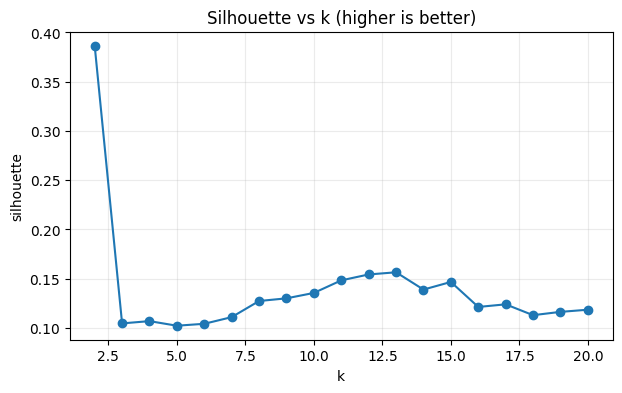

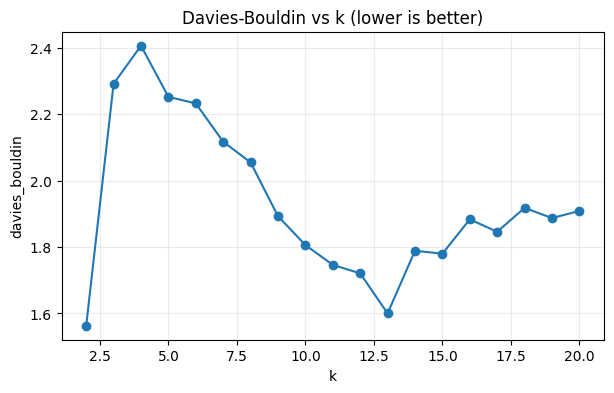

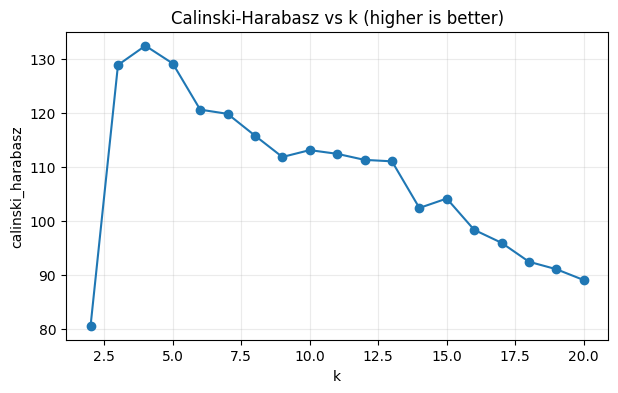

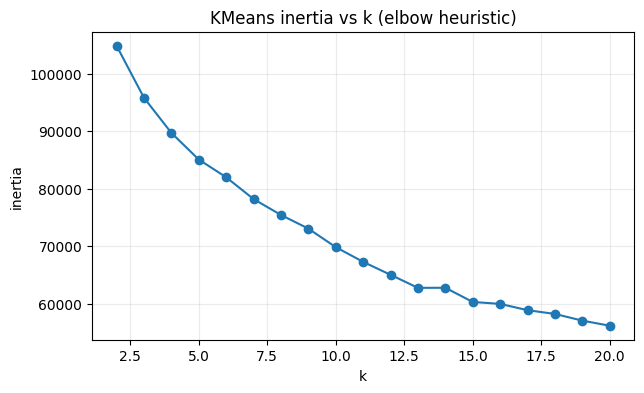

In [111]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, sil, marker="o")
plt.title("Silhouette vs k (higher is better)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_values, db, marker="o")
plt.title("Davies-Bouldin vs k (lower is better)")
plt.xlabel("k")
plt.ylabel("davies_bouldin")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_values, ch, marker="o")
plt.title("Calinski-Harabasz vs k (higher is better)")
plt.xlabel("k")
plt.ylabel("calinski_harabasz")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia, marker="o")
plt.title("KMeans inertia vs k (elbow heuristic)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.show()

Выбор k

На Digits “истинно” 10 классов, но мы делаем вид, что этого не знаем. Внутренние метрики часто дают максимум не на k=10 – и это нормально.

Практическая логика:

выбрать 2-3 “кандидатных” k по метрикам;
посмотреть устойчивость (разные random_state, n_init);
посмотреть интерпретируемость кластеров (что внутри кластеров?);
и только после этого фиксировать решение.

In [112]:
k = 10
labels_k10 = kmeans_labels(X_scaled, k=k)
print("k =", k)
print("silhouette:", round(silhouette_score(X_scaled, labels_k10), 3))
print("davies_bouldin:", round(davies_bouldin_score(X_scaled, labels_k10), 3))
print("calinski_harabasz:", round(calinski_harabasz_score(X_scaled, labels_k10), 1))

k = 10
silhouette: 0.136
davies_bouldin: 1.806
calinski_harabasz: 113.1


PCA - сжатие размерности и визуализация 2D

PCA ищет направления максимальной дисперсии. Это полезно, чтобы:

ускорять дальнейшие методы (включая t-SNE);
понимать, “сколько измерений реально нужно”;
строить 2D/3D-карты для анализа структуры.

Важно: PCA – линейный метод. Если структура нелинейная, PCA может не показать “красивые” группы.

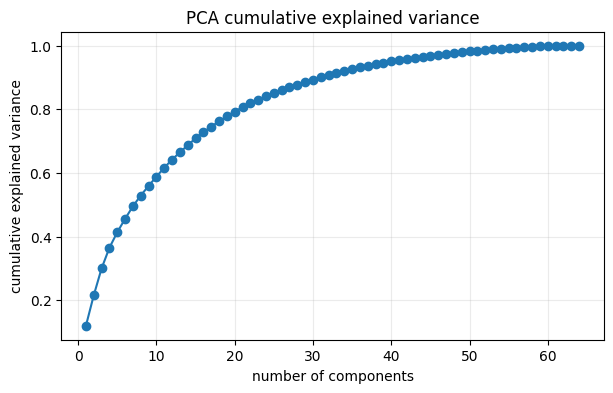

Variance explained by first 2 components: 0.216
Variance explained by first 10 components: 0.589


In [113]:
pca_full = PCA(random_state=rng)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cum = np.cumsum(explained)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cum) + 1), cum, marker="o")
plt.title("PCA cumulative explained variance")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.grid(True, alpha=0.25)
plt.show()

print("Variance explained by first 2 components:", round(cum[1], 3))
print("Variance explained by first 10 components:", round(cum[9], 3))

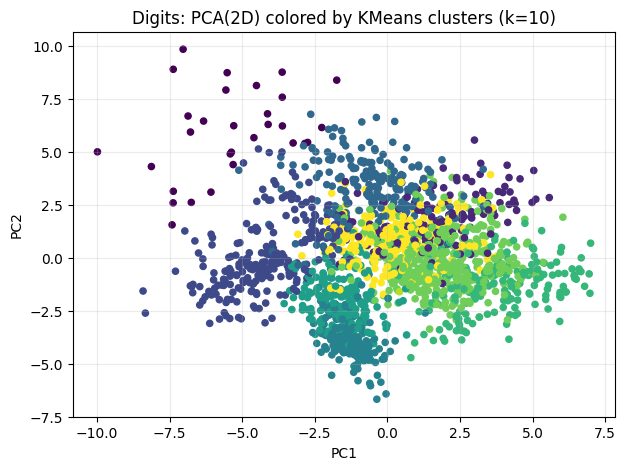

In [116]:
pca2 = PCA(n_components=2, random_state=rng)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels_k10, s=20)
plt.title("Digits: PCA(2D) colored by KMeans clusters (k=10)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

t-SNE - нелинейная карта локальной структуры

t-SNE старается сохранить локальные соседства в 2D. Это отлично для визуального анализа, но важно помнить:

t-SNE не оптимизирует silhouette/DB/CH и не “доказывает” хорошую кластеризацию;
глобальные расстояния на карте t-SNE часто нельзя интерпретировать буквально;
результат зависит от параметров (perplexity, learning_rate, init, random_state).
Хорошая практика:

сначала уменьшить размерность через PCA до 30–50 компонент (ускорение и шумоподавление),
потом запускать t-SNE.

In [ ]:
# уменьшаем размерность до 30 компонентов
pca30 = PCA(n_components=30, random_state=rng)
X_pca30 = pca30.fit_transform(X_scaled)
print("X_pca30.shape:", X_pca30.shape)

X_pca30.shape: (1797, 30)


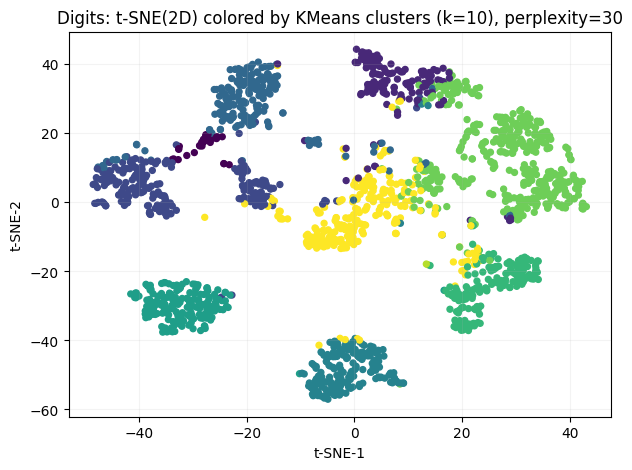

In [119]:
def tsne_embed(X, perplexity=30, learning_rate="auto", random_state=rng):
    # Параметры подобраны так, чтобы запуск был адекватным по времени на обычной машине.
    # Если медленно – уменьшайте n_iter или берите подвыборку.
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        random_state=random_state,
        max_iter=1000,
    )
    return tsne.fit_transform(X)

X_tsne = tsne_embed(X_pca30, perplexity=30)

plt.figure(figsize=(7, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_k10, s=18)
plt.title("Digits: t-SNE(2D) colored by KMeans clusters (k=10), perplexity=30")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.grid(True, alpha=0.15)
plt.show()

Влияние perplexity

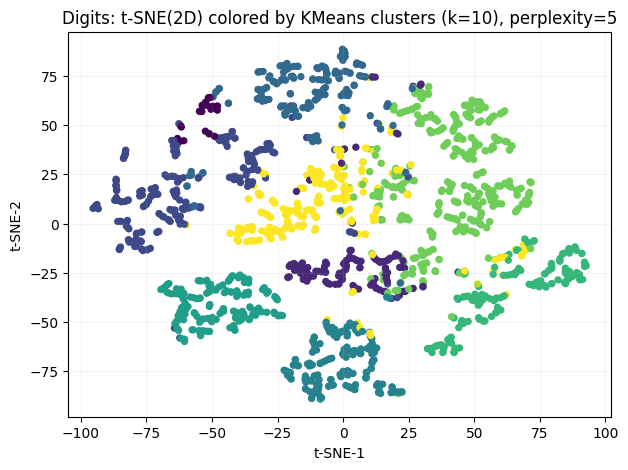

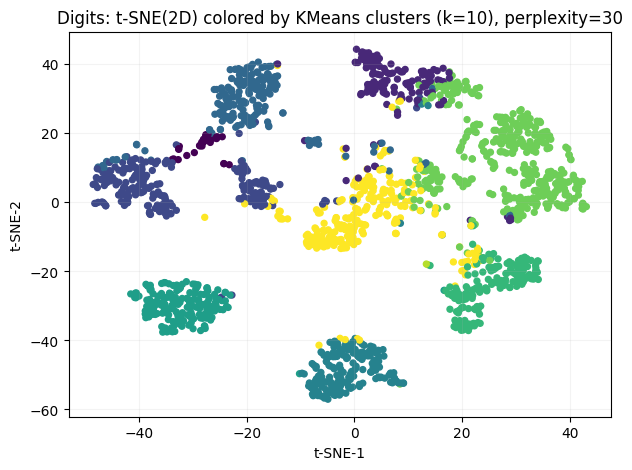

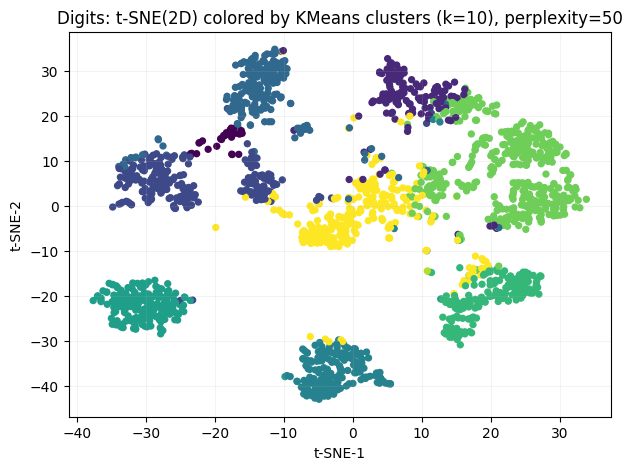

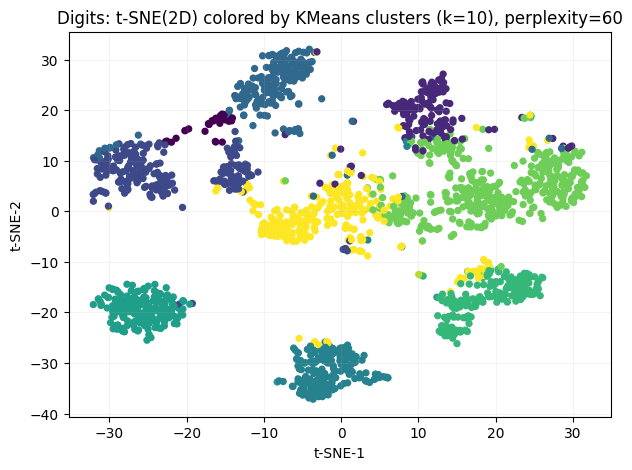

In [120]:
perplexities = [5, 30, 50, 60]

for p in perplexities:
    emb = tsne_embed(X_pca30, perplexity=p)
    plt.figure(figsize=(7, 5))
    plt.scatter(emb[:, 0], emb[:, 1], c=labels_k10, s=18)
    plt.title(f"Digits: t-SNE(2D) colored by KMeans clusters (k=10), perplexity={p}")
    plt.xlabel("t-SNE-1")
    plt.ylabel("t-SNE-2")
    plt.grid(True, alpha=0.15)
    plt.show()

Внешние метрики – только когда есть эталонные метки

В реальных задачах кластеризации истинных меток обычно нет. Но на Digits они есть, поэтому можно оценить “насколько кластеры похожи на классы” через:

ARI (Adjusted Rand Index): 1 – идеально, 0 – примерно случайно;
NMI (Normalized Mutual Information): 1 – идеально.

ARI  (true labels vs clusters): 0.531
NMI  (true labels vs clusters): 0.672


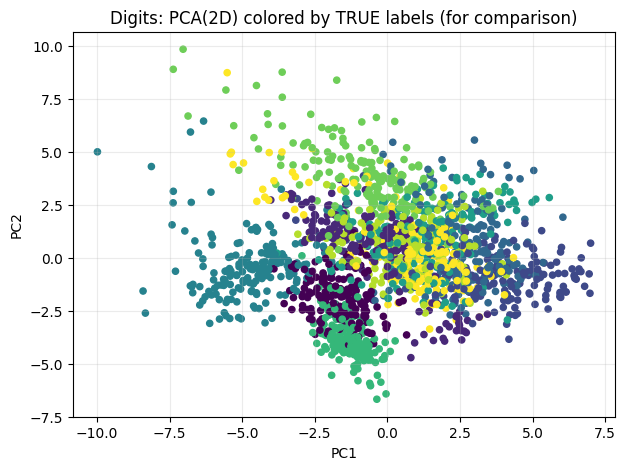

In [121]:
ari = adjusted_rand_score(y_true, labels_k10)
nmi = normalized_mutual_info_score(y_true, labels_k10)

print("ARI  (true labels vs clusters):", round(ari, 3))
print("NMI  (true labels vs clusters):", round(nmi, 3))

# Визуализация PCA(2D) с истинными классами для сравнения
plt.figure(figsize=(7, 5))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_true, s=20)
plt.title("Digits: PCA(2D) colored by TRUE labels (for comparison)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

Датасет Wine

Wine X.shape: (178, 13)
Wine classes: [0 1 2]
Wine k=3 silhouette: 0.285
Wine ARI (bonus): 0.897


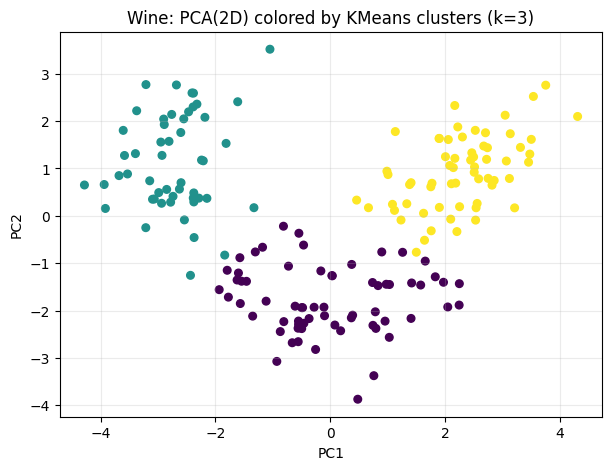

In [123]:

wine = load_wine()
Xw = wine.data
yw = wine.target

print("Wine X.shape:", Xw.shape)
print("Wine classes:", np.unique(yw))

Xw_scaled = StandardScaler().fit_transform(Xw)

k = 3
labels_w = kmeans_labels(Xw_scaled, k=k)

print("Wine k=3 silhouette:", round(silhouette_score(Xw_scaled, labels_w), 3))
print("Wine ARI (bonus):", round(adjusted_rand_score(yw, labels_w), 3))

# PCA(2D) для Wine
Xw_pca2 = PCA(n_components=2, random_state=rng).fit_transform(Xw_scaled)
plt.figure(figsize=(7, 5))
plt.scatter(Xw_pca2[:, 0], Xw_pca2[:, 1], c=labels_w, s=30)
plt.title("Wine: PCA(2D) colored by KMeans clusters (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

Выводы:

Внутренние метрики (silhouette/DB/CH) помогают сравнить варианты, но не дают “абсолютной истины”.
PCA полезна как инструмент сжатия и понимания структуры, особенно перед t-SNE.
t-SNE – мощная визуализация локальной структуры, но её легко переинтерпретировать.
Если есть истинные метки (редко в реальности) – можно дополнительно проверить ARI/NMI как учебный контроль.